# Coffee Futures Quantitative Analysis

Using the provided market data, apply the cost of carry model, the Black-Scholes model, and Monte Carlo simulations to determine the fair price of a coffee option contract. Analyze how changes in supply, demand, weather, and geopolitical factors might impact your pricing.

**Given:**

- *Current spot price (St):* $1.20 per pound
  
- *Risk-free rate (r):* 2% per annum
- *Storage cost (d):* 1% per annum
- *Time to maturity (T):* 6 months (0.5 years)
- *Strike price (X)*: $1.25
- *Volatility (σ):* 25% 

## Cost of Carry Model
**Project:** Calculate the futures price for a coffee contract maturing in six months using the current spot price, the risk-free interest rate, and the estimated storage costs.

**Steps:**

1.	**Gather Data:**
    - *Spot Price:* Find the current spot price of coffee. You can obtain this from financial news websites like Bloomberg, Reuters, or commodity-specific sites like the International Coffee Organization (ICO).
    - *Risk-Free Rate:* Use the current yield on a six-month US Treasury bill as a proxy for the risk-free rate. This data can be found on financial websites like the US Department of the Treasury or FRED (Federal Reserve Economic Data).
    - *Storage Costs:* Estimate storage costs as a percentage of the spot price. This information might be available in commodity market reports or industry publications.


3.	**Calculate Futures Price:**
    - Use the cost of carry formula:
     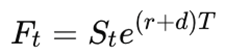

    - Where:
        - Ft: Futures price
        - St: Spot price
        - r: Risk-free rate
        - d: Storage cost
        - T: Time to maturity (0.5 years for six months)

In [1]:
import numpy as np

# Given values
S_t = 1.20  # Spot price in dollars
r = 0.02  # Risk-free rate (2%)
d = 0.01  # Storage cost (1%)
T = 0.5  # Time to maturity in years

# Calculating futures price
F_t = S_t * np.exp((r + d) * T)
print(f"The fair price of the coffee futures contract is ${F_t:.3f} per pound.")

The fair price of the coffee futures contract is $1.218 per pound.


## Black-Scholes Model
**Project:** Price a call option on a coffee futures contract using the current spot price, strike price, risk-free rate, time to maturity, and volatility.

**Steps:**

1.	**Gather Data:**
    - *Spot Price:* Use the same spot price data as for the futures contract.
    - *Strike Price:* Choose a strike price based on market conditions and option contracts available on exchanges like the ICE (Intercontinental Exchange).
    - *Risk-Free Rate:* Use the same risk-free rate as for the futures contract.
    - *Time to Maturity:* Specify the time to maturity (e.g., six months).
    - *Volatility:* Calculate or find the historical volatility of coffee prices. This data can be derived from historical price data available on financial websites or through databases like Yahoo Finance.


2.	**Calculate Futures Price:**
    - Use the Black-Scholes formula:
      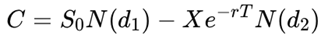      
      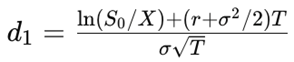
      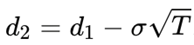
      
    - Where:
        - C: Call option price
        - S0: Spot price
        - X: Strike price
        - r: Risk-free rate
        - T: Time to maturity
        - σ: Volatility

In [3]:
from scipy.stats import norm
import numpy as np

# Given values
S_0 = 1.20  # Spot price in dollars
X = 1.25  # Strike price in dollars
r = 0.02  # Risk-free rate (2%)
T = 0.5  # Time to maturity in years
sigma = 0.25  # Volatility (25%)

# Calculating d1 and d2
d1 = (np.log(S_0 / X) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

# Calculating call option price using Black-Scholes formula
C = S_0 * norm.cdf(d1) - X * np.exp(-r * T) * norm.cdf(d2)
print(f"The price of the call option is ${C:.3f}.")

The price of the call option is $0.068.


## Monte Carlo Simulation
**Project:** Run simulations to forecast the price of coffee futures under different market conditions. Evaluate the impact of varying supply, demand, and weather scenarios.

**Steps:**

1.	**Gather Data:**
    - *Initial Price:* Use the same spot price data.
    - *Risk-Free Rate:* Use the same risk-free rate.
    -  *Volatility:* Use the same volatility data.
    -  *Simulated Period:* Define the time period for the simulation (e.g., six months).

3.	**Run Simulations:**
    - Use Monte Carlo simulations to generate numerous possible future price paths based on the inputs.
    - Model the stochastic process of coffee prices using Geometric Brownian Motion (GBM).

In [4]:
import numpy as np

# Simulation parameters
S_0 = 1.20  # Spot price in dollars
r = 0.02  # Risk-free rate (2%)
sigma = 0.25  # Volatility (25%)
T = 0.5  # Time to maturity in years
num_simulations = 10000

# Running Monte Carlo simulation
np.random.seed(42)  # For reproducibility
simulated_prices = S_0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * np.random.randn(num_simulations))

# Calculating the average simulated price
average_simulated_price = np.mean(simulated_prices)
print(f"The average simulated price of the coffee futures contract is ${average_simulated_price:.3f}.")

The average simulated price of the coffee futures contract is $1.212.


So based on above method, the fair price of the coffee futures contract is approximately $1.218 per pound by using the Cost of Carry Model.